In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [12]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [16]:
df.size

132140

In [18]:
df.shape

(6607, 20)

In [20]:
# 1. Check for Missing Values
# Detect and count missing values in the dataset
missing_values = df.isnull().sum()
missing_values

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [22]:
# Fill missing values for categorical columns with the most frequent value (mode)  
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])  
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0])  

# Now, recheck for any remaining missing values  
print(df.isnull().sum())  

# Save cleaned data  
df.to_csv('cleaned_students_data.csv', index=False)  

# View the cleaned data  
print(df.head())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality                0
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level       0
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89       

In [24]:
# Filter numerical columns only
numerical_cols = df.select_dtypes(include=[np.number])

# 2. Detect and Handle Outliers
# We use the IQR (Interquartile Range) method to detect outliers in numerical columns
Q1 = numerical_cols.quantile(0.25)
Q3 = numerical_cols.quantile(0.75)
IQR = Q3 - Q1

# Filter out outliers using the IQR method
df_clean = df[~((numerical_cols < (Q1 - 1.5 * IQR)) | (numerical_cols > (Q3 + 1.5 * IQR))).any(axis=1)]

In [26]:
# View the cleaned data
print(df_clean.head())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [28]:
df.duplicated()
#To detect duplicates 

0       False
1       False
2       False
3       False
4       False
        ...  
6602    False
6603    False
6604    False
6605    False
6606    False
Length: 6607, dtype: bool

In [30]:
# 5. Remove Duplicates
# Check for and drop duplicate rows
df = df.drop_duplicates()

In [32]:
# Dropping irrelevant columns
df = df.drop(['Distance_from_Home'], axis=1) 

In [34]:
df = df.drop(columns= "Peer_Influence")
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,3,No,High School,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,4,No,College,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,4,No,Postgraduate,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,4,No,High School,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,4,No,College,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,2,No,High School,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,2,No,High School,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,2,No,Postgraduate,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,3,No,High School,Female,68


In [36]:
for x in df.index: #loops through all the numerical % columns and checks if any values are over 100 or negative if over 100 it replaces that number with 100 if negative it replaces that number with 0
    if df.loc[x, "Attendance"] > 100:
        df.loc[x, "Attendance"] = 100  # Set to 100
    elif df.loc[x, "Attendance"] < 0:
        df.loc[x, "Attendance"] = 0  # Set to 0 
for x in df.index:
    if df.loc[x, "Previous_Scores"] > 100:
        df.loc[x, "	Previous_Scores"] = 100  # Set to 100
    elif df.loc[x, "Previous_Scores"] < 0:
        df.loc[x, "Previous_Scorese"] = 0  # Set to 0
for x in df.index:
    if df.loc[x, "Exam_Score"] > 100:
        df.loc[x, "Exam_Score"] = 100  # Set to 100
    elif df.loc[x, "Exam_Score"] < 0:
        df.loc[x, "Exam_Score"] = 0  # Set to 0

In [110]:
for x in df.index: #Check that for numerical values in these specific columns are not negative. if negative change value to zero
    if df.loc[x, "Hours_Studied"] <0:
        df.loc[x, "Hours_Studied"] = 0 

for x in df.index: #These loop codes deal with outliers
    if df.loc[x, "Sleep_Hours"] <0:
        df.loc[x, "Sleep_Hours"] = 0 

for x in df.index:
    if df.loc[x, "Tutoring_Sessions"] <0:
        df.loc[x, "Tutoring_Sessions"] = 0 

for x in df.index:
    if df.loc[x, "Physical_Activity"] <0:
        df.loc[x, "Physical_Activity"] = 0 
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,3,No,High School,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,4,No,College,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,4,No,Postgraduate,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,4,No,High School,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,4,No,College,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,2,No,High School,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,2,No,High School,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,2,No,Postgraduate,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,3,No,High School,Female,68


In [111]:
df = df.map(lambda x: x.strip() if isinstance(x, str) else x) #like Strip but removes all white space from strings in every column
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,3,No,High School,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,4,No,College,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,4,No,Postgraduate,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,4,No,High School,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,4,No,College,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,2,No,High School,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,2,No,High School,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,2,No,Postgraduate,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,3,No,High School,Female,68


In [38]:
df = df.replace('NaN','')
df.fillna('')

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,3,No,High School,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,4,No,College,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,4,No,Postgraduate,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,4,No,High School,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,4,No,College,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,2,No,High School,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,2,No,High School,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,2,No,Postgraduate,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,3,No,High School,Female,68


In [114]:
df_dropped = df.dropna() #droping all missing values in the dataset
print(df_dropped)

      Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0                23          84                  Low                High   
1                19          64                  Low              Medium   
2                24          98               Medium              Medium   
3                29          89                  Low              Medium   
4                19          92               Medium              Medium   
...             ...         ...                  ...                 ...   
6602             25          69                 High              Medium   
6603             23          76                 High              Medium   
6604             20          90               Medium                 Low   
6605             10          86                 High                High   
6606             15          67               Medium                 Low   

     Extracurricular_Activities  Sleep_Hours  Previous_Scores  \
0                     

In [115]:
df = df.reset_index(drop=True) #reseting the index when rows have been dropped/ removed
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,3,No,High School,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,4,No,College,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,4,No,Postgraduate,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,4,No,High School,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,4,No,College,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,2,No,High School,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,2,No,High School,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,2,No,Postgraduate,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,3,No,High School,Female,68


In [116]:
# 7. Save Cleaned Data to a New CSV
df.to_csv(r'cleaned_students_data.csv', index=False)

In [118]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,3,No,High School,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,4,No,College,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,4,No,Postgraduate,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,4,No,High School,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,4,No,College,Female,70


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   object
 13  Physical_Activity           6607 non-null   int6

In [120]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235508
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.889161
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,100.000000


In [121]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Gender                        0
Exam_Score                    0
dtype: int64

In [122]:
df.nunique()

Hours_Studied                 41
Attendance                    41
Parental_Involvement           3
Access_to_Resources            3
Extracurricular_Activities     2
Sleep_Hours                    7
Previous_Scores               51
Motivation_Level               3
Internet_Access                2
Tutoring_Sessions              9
Family_Income                  3
Teacher_Quality                3
School_Type                    2
Physical_Activity              7
Learning_Disabilities          2
Parental_Education_Level       3
Gender                         2
Exam_Score                    44
dtype: int64

In [124]:
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,3,No,High School,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,4,No,College,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,4,No,Postgraduate,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,4,No,High School,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,4,No,College,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,2,No,High School,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,2,No,High School,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,2,No,Postgraduate,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,3,No,High School,Female,68


In [125]:
df.sort_values(by = "Hours_Studied").head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Gender,Exam_Score
262,1,69,High,Medium,Yes,6,97,Medium,Yes,1,Low,Medium,Public,3,No,High School,Female,61
4725,1,81,Medium,Medium,Yes,8,66,Medium,Yes,1,Low,Medium,Public,2,No,College,Male,60
4779,1,88,Medium,High,Yes,4,72,High,Yes,3,Medium,Medium,Private,2,No,College,Male,92
3454,2,99,Medium,Low,Yes,9,52,Low,Yes,0,Medium,Medium,Public,4,No,High School,Male,62
2947,2,67,Medium,Medium,No,6,73,Low,Yes,1,Low,Medium,Private,2,No,College,Male,58


In [128]:
df.sort_values(by = "Hours_Studied", ascending = False).head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Gender,Exam_Score
2895,44,68,High,Low,No,9,75,Low,Yes,3,Medium,High,Private,2,No,High School,Female,71
209,43,86,High,Medium,Yes,7,97,Medium,Yes,2,Medium,High,Public,1,No,High School,Female,78
1615,39,95,Medium,High,Yes,9,54,High,Yes,2,Medium,Medium,Private,3,No,High School,Male,77
2305,39,92,Medium,Medium,No,9,73,Medium,Yes,1,Medium,Medium,Public,4,No,Postgraduate,Male,75
3982,39,75,Medium,High,Yes,6,82,High,Yes,1,High,Low,Public,3,No,College,Male,73
1957,39,97,High,High,Yes,10,91,Medium,Yes,2,Low,Medium,Public,3,No,High School,Female,79
4997,39,67,High,High,Yes,5,76,Medium,No,2,Medium,Medium,Private,4,No,High School,Female,71
5796,39,78,Medium,Medium,No,6,73,Medium,Yes,0,Low,Medium,Public,2,No,College,Male,70
3716,39,90,High,High,No,8,92,High,Yes,2,Medium,High,Private,1,No,High School,Female,78
2521,38,86,High,Medium,No,6,88,High,Yes,1,Low,High,Public,4,No,High School,Female,74


In [130]:
df.sort_values(by = "Exam_Score", ascending = False).head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,3,No,High School,Female,100
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,High,Medium,Private,2,No,College,Female,100
2425,23,83,High,High,Yes,4,89,Low,Yes,1,Medium,Medium,Public,3,No,High School,Male,99
3579,14,90,High,High,Yes,8,86,Medium,Yes,4,Medium,Medium,Private,2,No,High School,Female,99
6393,16,83,Low,Medium,Yes,8,92,Low,Yes,2,High,High,Public,4,No,Postgraduate,Female,98
6347,28,96,High,Low,Yes,4,98,High,Yes,1,High,High,Public,3,No,High School,Male,98
4192,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,Medium,Medium,Public,2,No,College,Female,98
919,21,74,High,Medium,No,6,94,Medium,Yes,1,Low,High,Public,1,No,High School,Male,97
529,15,83,Medium,Medium,No,7,97,Medium,Yes,2,Low,High,Private,2,No,High School,Female,97
5966,25,99,Medium,Medium,Yes,7,77,Medium,Yes,0,High,High,Public,3,No,High School,Male,97


In [131]:
df.dtypes.to_frame(name='Data Type')

,Data Type
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


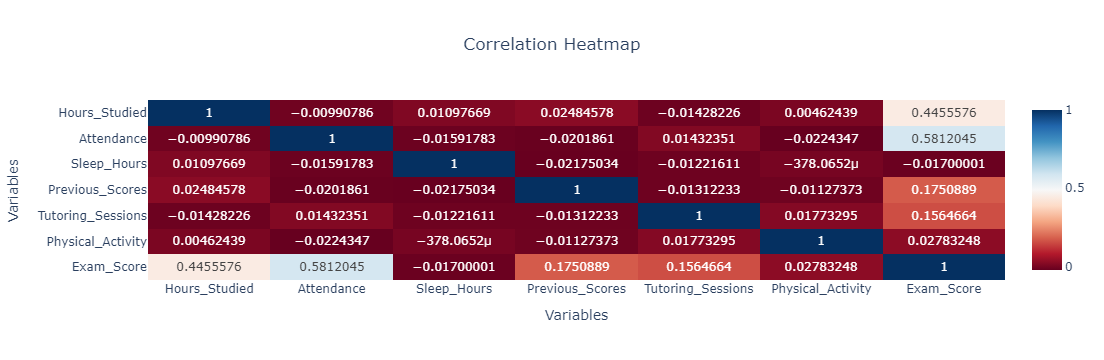

In [62]:
numeric_df = df.select_dtypes(include=[np.number])  # Selecting only numeric columns
correlation_matrix = numeric_df.corr() 


# Creating an interactive heatmap using Plotly  
heatmap_fig = px.imshow(correlation_matrix,   
                         text_auto=True,  # To show correlation coefficients on the heatmap  
                         color_continuous_scale='RdBu',   
                         title='Correlation Heatmap',   
                         aspect='auto')  

# Updating layout for better appearance  
heatmap_fig.update_layout(xaxis_title='Variables',   
                           yaxis_title='Variables',   
                           title_x=0.5)  # Center the title  

heatmap_fig.show()  

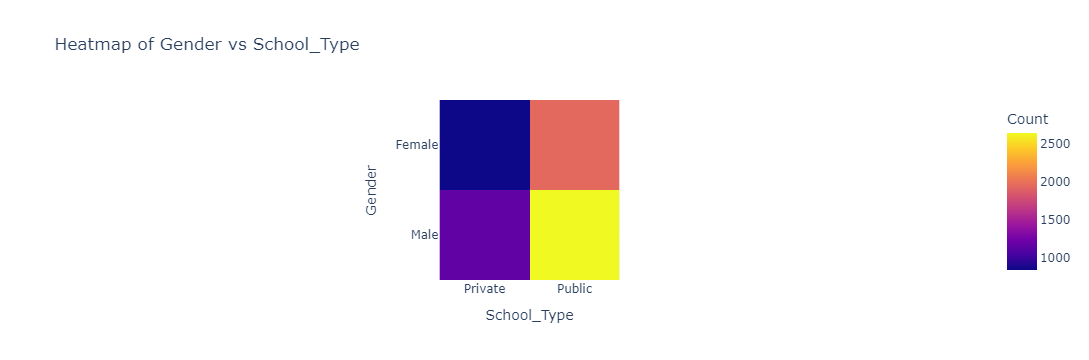

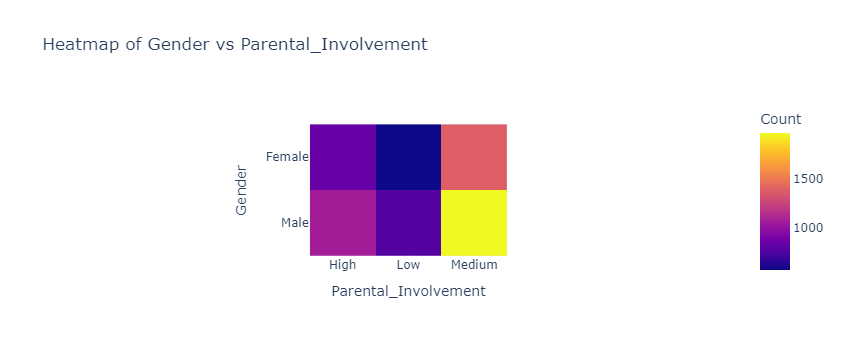

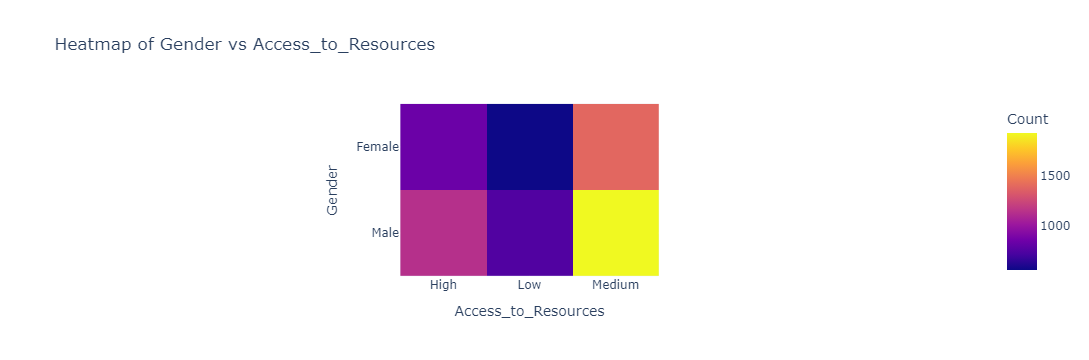

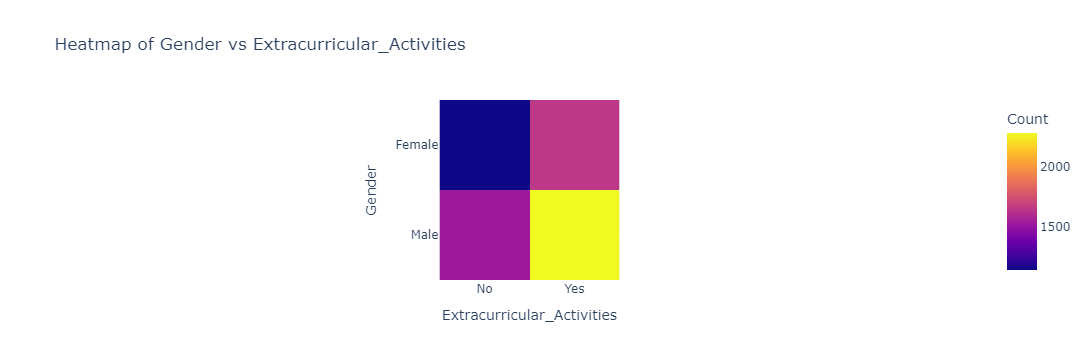

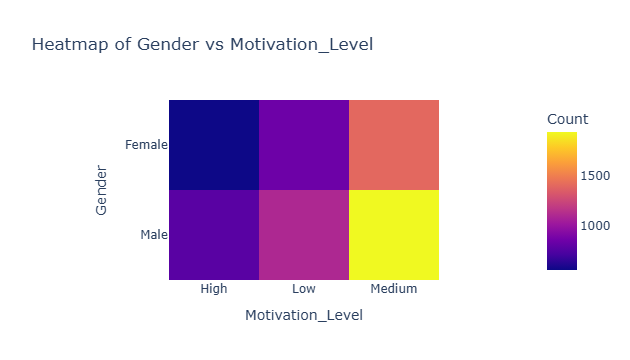

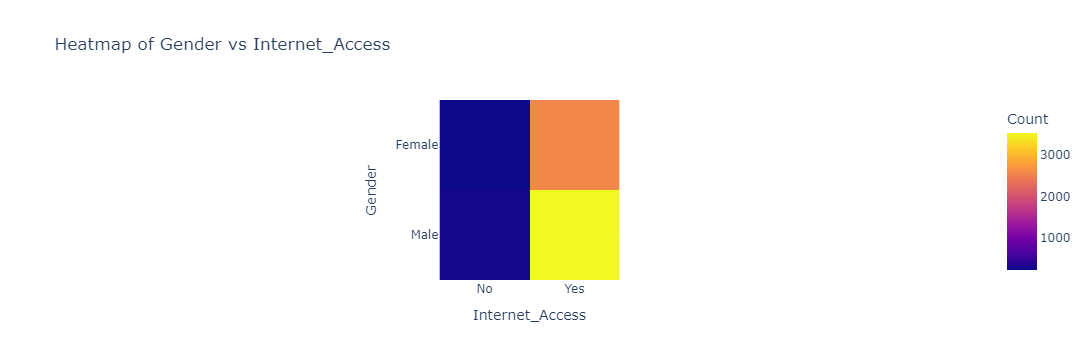

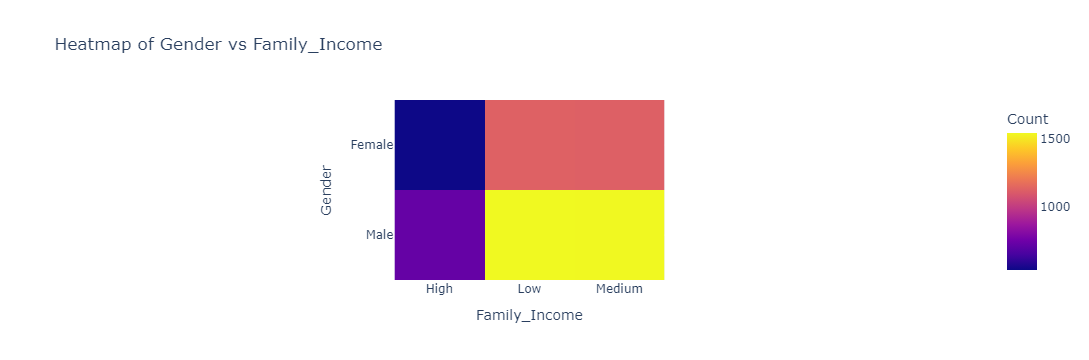

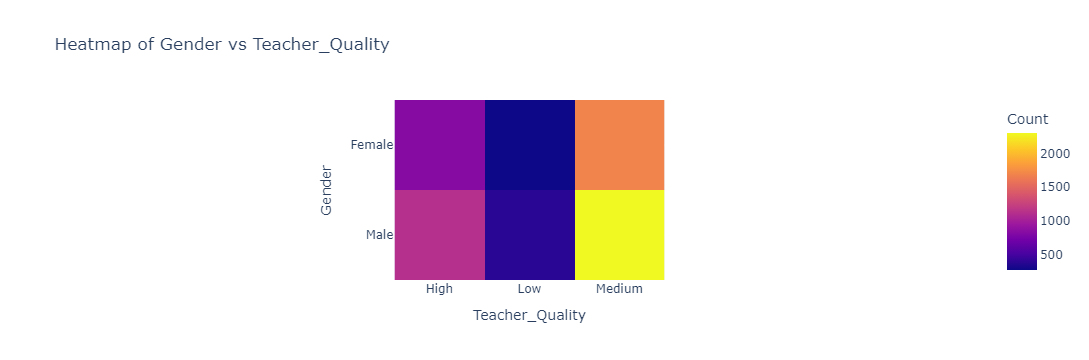

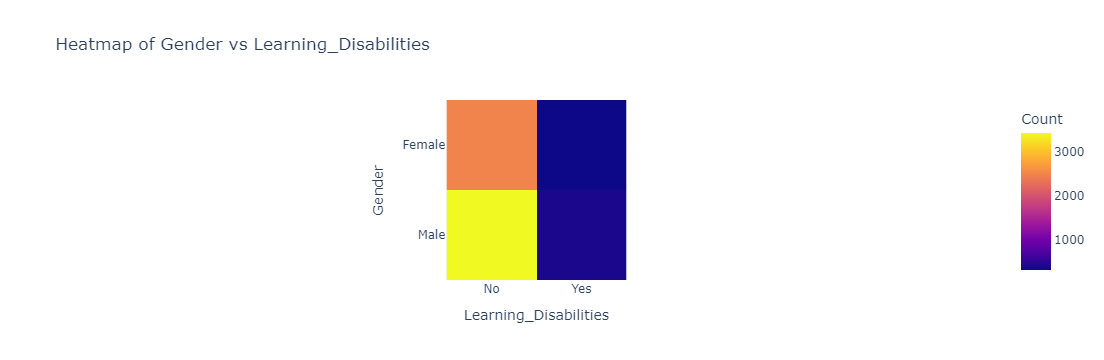

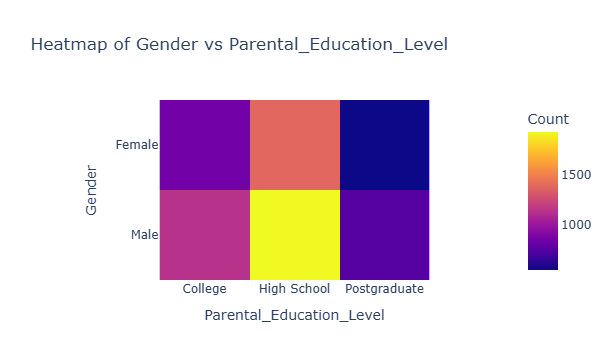

KeyError: 'Distance_from_Home'

In [99]:
categorical_columns = ['Gender', 'School_Type', 'Parental_Involvement', 'Access_to_Resources', 
                       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 
                       'Family_Income', 'Teacher_Quality', 
                       'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home']

# Create heatmaps for each pair of categorical columns
for col1 in categorical_columns:
    for col2 in categorical_columns:
        if col1 != col2:
            # Create a contingency table
            contingency_table = pd.crosstab(df[col1], df[col2])
            
            # Create the heatmap
            heatmap_fig = px.imshow(contingency_table, 
                                    labels=dict(x=col2, y=col1, color="Count"),
                                    title=f"Heatmap of {col1} vs {col2}")
            
            # Show the heatmap
            heatmap_fig.show()


In [134]:
# Grouping by "Gender" and calculate mean only for numeric columns  
mean_values = df.groupby("Gender").mean(numeric_only=True)  

# Displaying the mean values  
mean_values

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Gender,,,,,,,
Female,20.005013,79.868958,7.041890,75.053348,1.503401,2.961332,67.244540
Male,19.953592,80.056896,7.019664,75.083115,1.486628,2.972208,67.228894


In [135]:
df = pd.read_csv(r"C:\Users\hofen\Downloads\cleaned_students_data.csv")
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,3,No,High School,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,4,No,College,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,4,No,Postgraduate,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,4,No,High School,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,4,No,College,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,2,No,High School,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,2,No,High School,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,2,No,Postgraduate,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,3,No,High School,Female,68


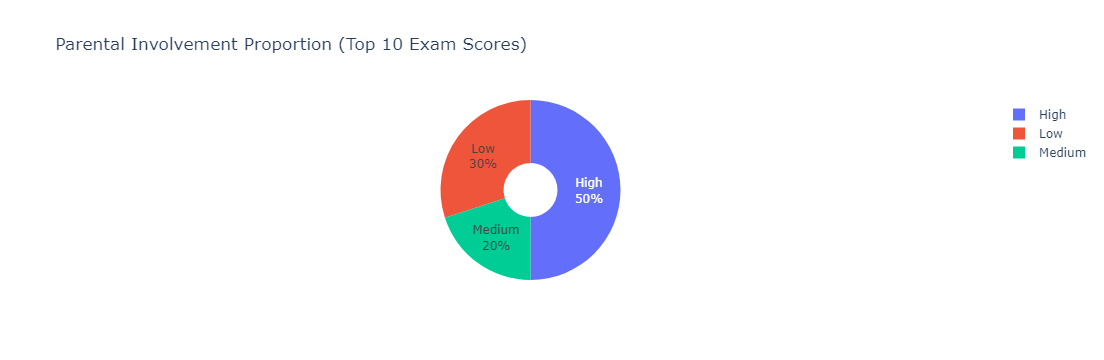

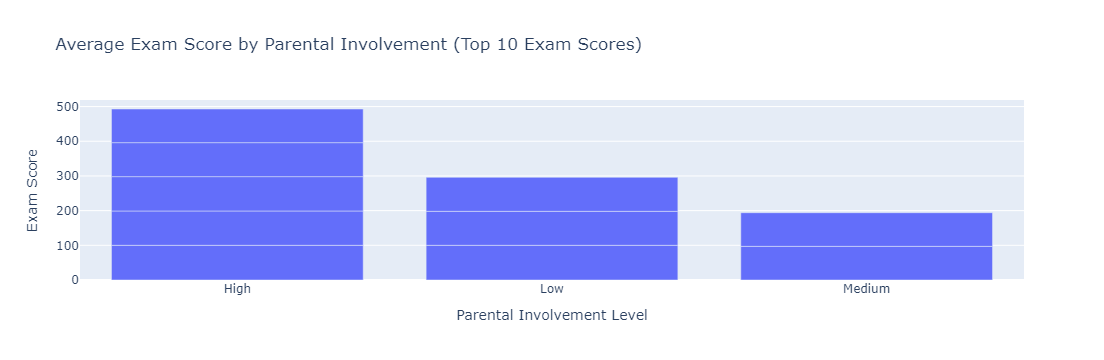

In [137]:
# Checking the top 10 based on Exam Score  
top_10_df = df.nlargest(10, 'Exam_Score')  

# Interactive Pie Chart for Parental Involvement for top 10  
pie_fig = px.pie(top_10_df,   
                 names='Parental_Involvement',   
                 title='Parental Involvement Proportion (Top 10 Exam Scores)',   
                 hole=0.3)  # Using donut chart style  

pie_fig.update_traces(textinfo='percent+label')  # percentage and label info  
pie_fig.show()  

# Interactive Bar Plot for Exam Score vs. Parental Involvement for top 10  
bar_fig = px.bar(top_10_df,   
                 x='Parental_Involvement',   
                 y='Exam_Score',  
                 title='Average Exam Score by Parental Involvement (Top 10 Exam Scores)',  
                 labels={'Parental_Involvement':'Parental Involvement Level', 'Exam_Score':'Exam Score'},  
                 category_orders={'Parental_Involvement': top_10_df['Parental_Involvement'].value_counts().index})  # Ensures order  

bar_fig.update_layout(xaxis_title='Parental Involvement Level',  
                      yaxis_title='Exam Score')  
bar_fig.show()  

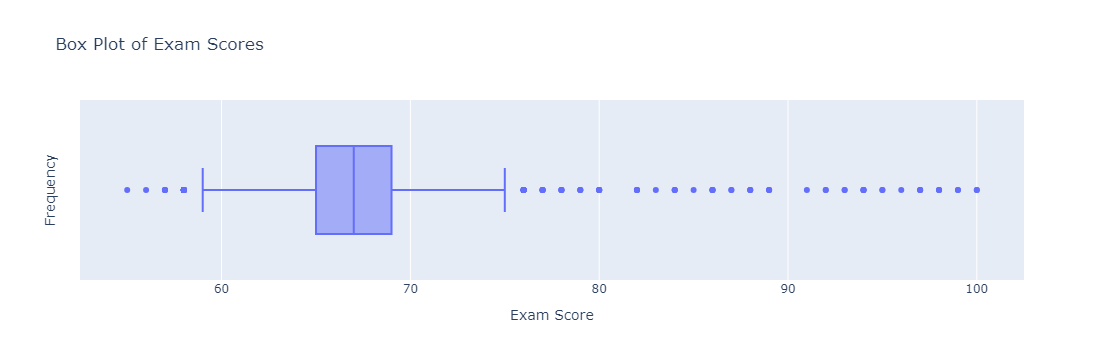

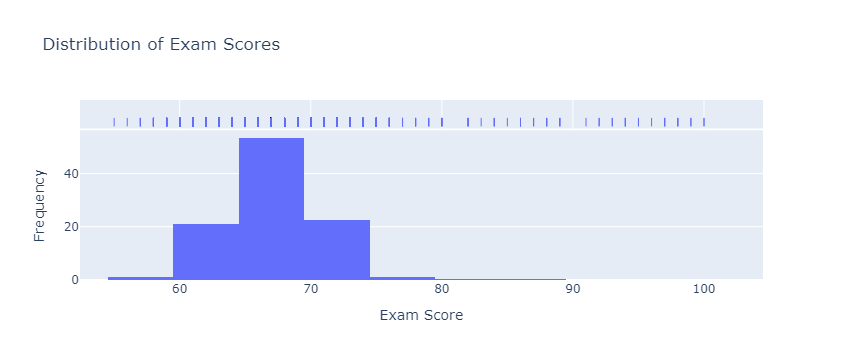

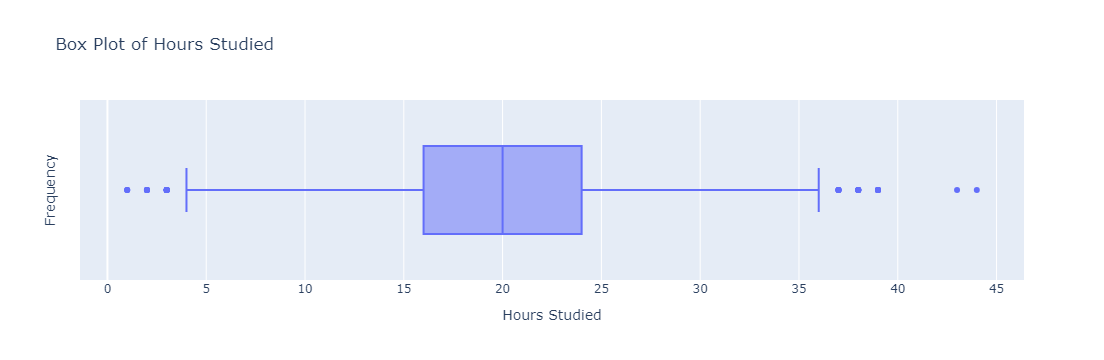

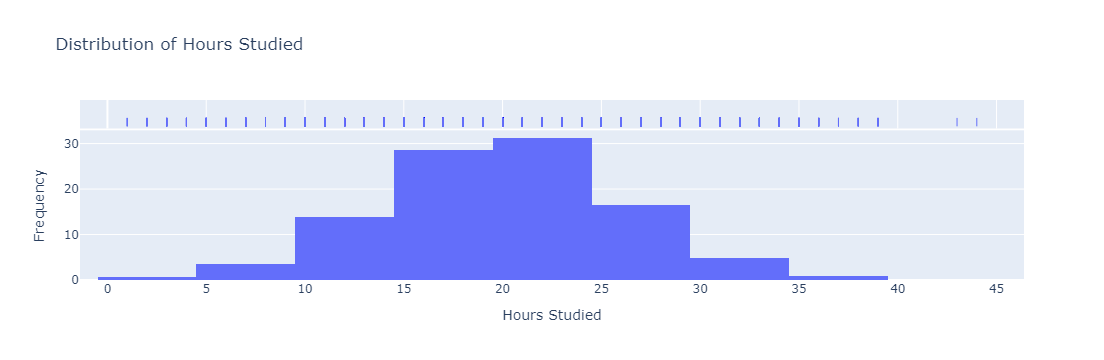

In [138]:
# **Box Plot for Exam Scores**  
box_fig_exam = px.box(df,   
                       x='Exam_Score',   
                       title='Box Plot of Exam Scores')  
box_fig_exam.update_layout(xaxis_title='Exam Score',   
                            yaxis_title='Frequency')  
box_fig_exam.show()  

# **Distribution Plot for Exam Scores**  
dist_fig_exam = px.histogram(df,   
                              x='Exam_Score',   
                              nbins=10,   
                              title='Distribution of Exam Scores',   
                              marginal='rug',  
                              histnorm='percent')  
dist_fig_exam.update_layout(xaxis_title='Exam Score',   
                             yaxis_title='Frequency')  
dist_fig_exam.show()  

# **Box Plot for Hours Studied**  
box_fig_hours = px.box(df,   
                        x='Hours_Studied',   
                        title='Box Plot of Hours Studied')  
box_fig_hours.update_layout(xaxis_title='Hours Studied',   
                             yaxis_title='Frequency')  
box_fig_hours.show()  

# **Distribution Plot for Hours Studied**  
dist_fig_hours = px.histogram(df,   
                               x='Hours_Studied',   
                               nbins=10,   
                               title='Distribution of Hours Studied',   
                               marginal='rug',  
                               histnorm='percent')  
dist_fig_hours.update_layout(xaxis_title='Hours Studied',   
                              yaxis_title='Frequency')  
dist_fig_hours.show()  

In [13]:
df.value_counts()

Hours_Studied  Attendance  Parental_Involvement  Access_to_Resources  Extracurricular_Activities  Sleep_Hours  Previous_Scores  Motivation_Level  Internet_Access  Tutoring_Sessions  Family_Income  Teacher_Quality  School_Type  Peer_Influence  Physical_Activity  Learning_Disabilities  Parental_Education_Level  Distance_from_Home  Gender  Exam_Score
1              69          High                  Medium               Yes                         6            97               Medium            Yes              1                  Low            Medium           Public       Positive        3                  No                     High School               Near                Female  61            1
23             64          Low                   Medium               Yes                         7            69               High              Yes              4                  High           Medium           Public       Positive        3                  No                     High Schoo

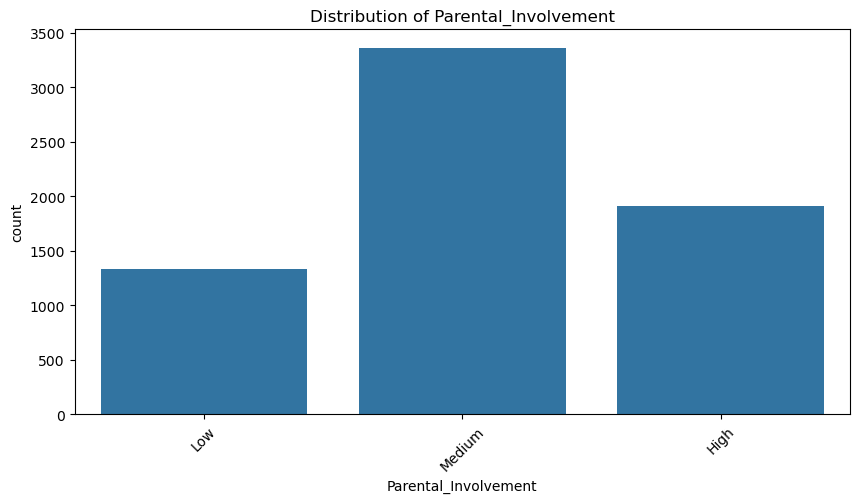

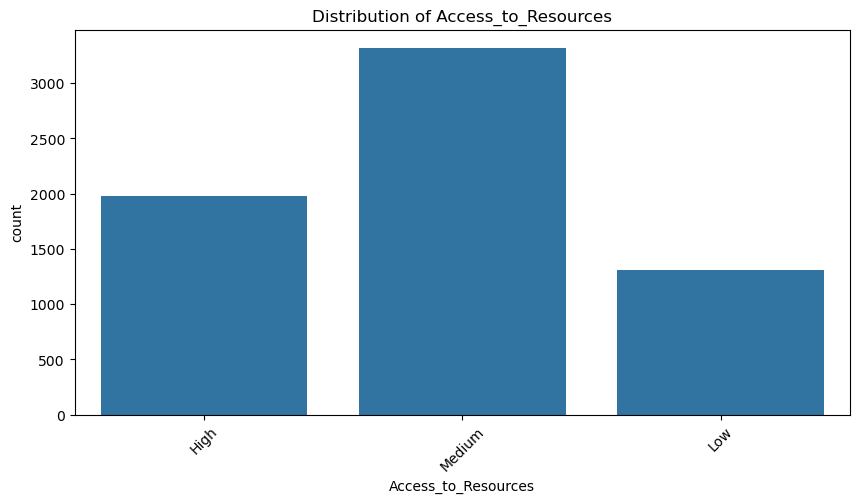

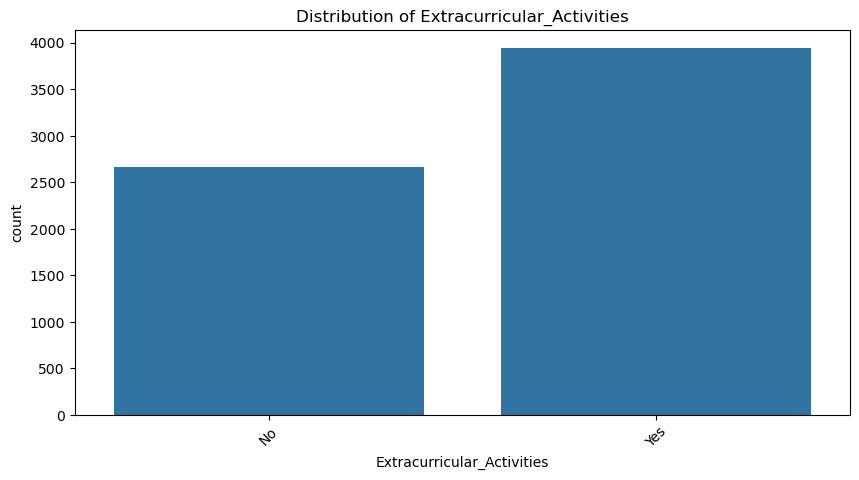

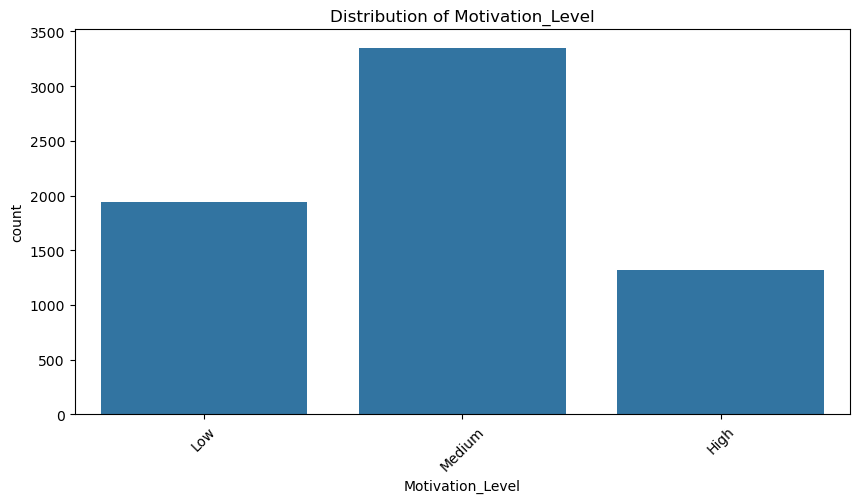

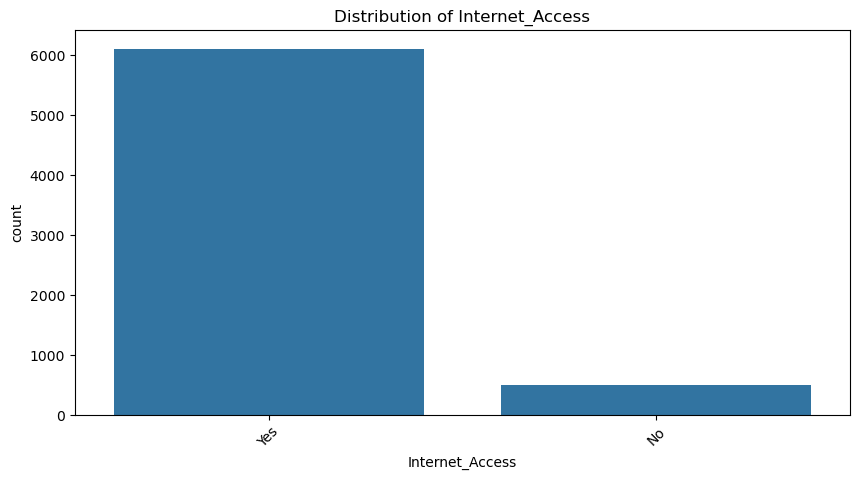

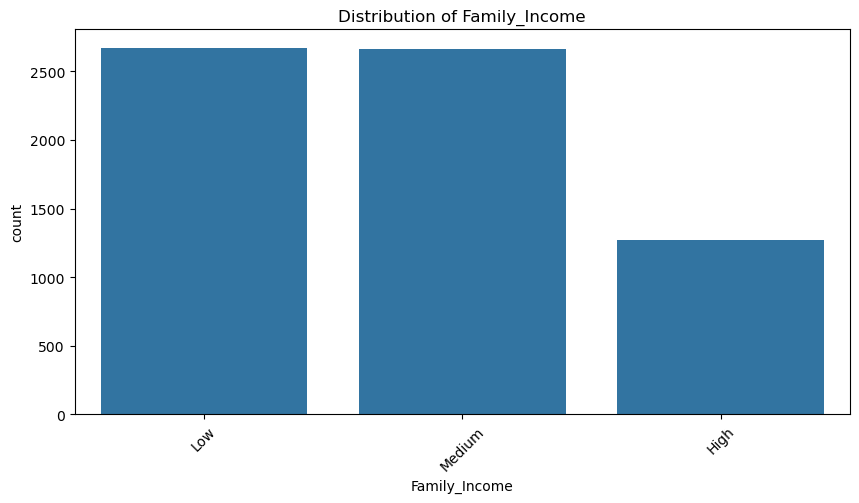

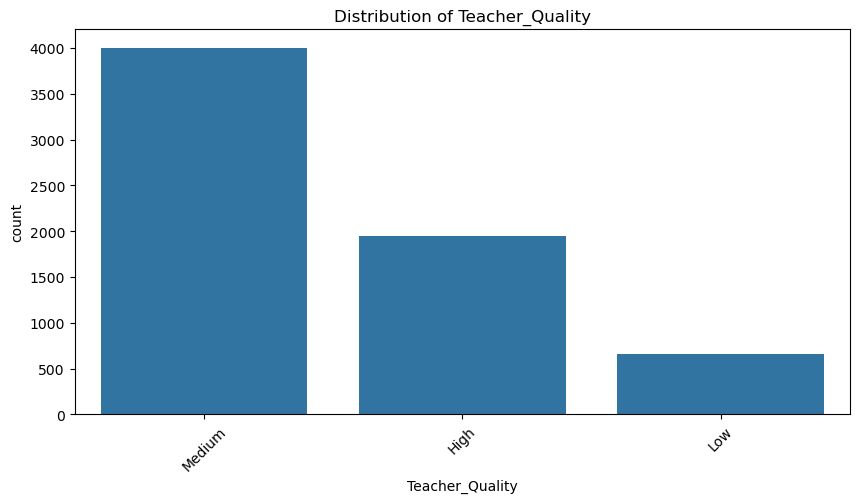

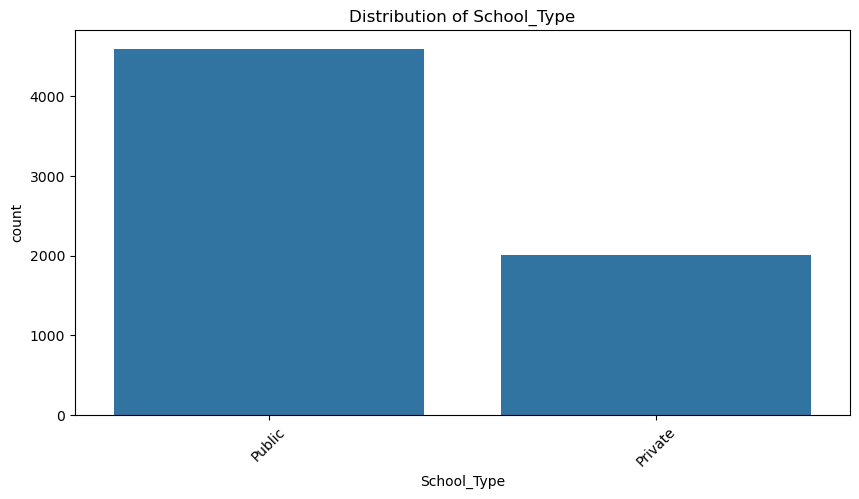

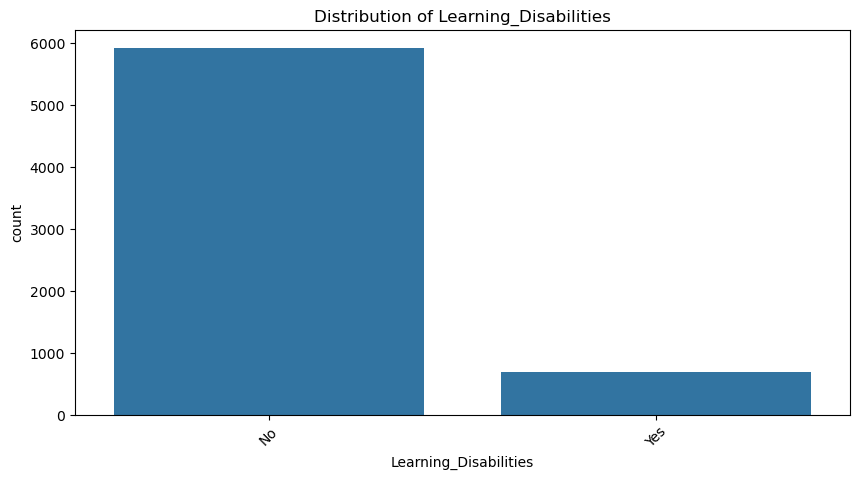

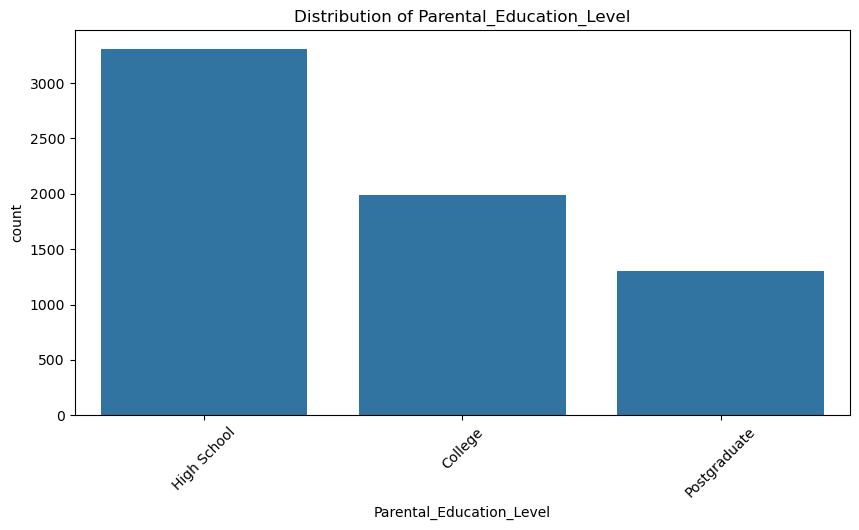

ValueError: Could not interpret value `Distance_from_Home` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>

In [103]:

# Bar plot for categorical variables
categorical_columns = ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 
                       'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 
                       'School_Type', 'Learning_Disabilities', 'Parental_Education_Level', 
                       'Distance_from_Home', 'Gender']

for col in categorical_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()


# Preprocessing

In [ ]:
dataset = pd.read_csv('cleaned_students_data.csv')

In [ ]:
dataset.columns.values

In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

### Columns that require one-hot encoding (nomial categorical)

In [ ]:
one_hot_columns = ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',
                  'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 
                  'School_Type', 'Learning_Disabilities', 'Gender']

### Columns that require ordinal encoding (categorical with order)

In [ ]:
ordinal_columns = ['Parental_Education_Level']

### Define an order for the 'Parental_Education_Level' columns

In [ ]:
education_order = ['High School', 'College', 'Postgraduate']

### Applying ordinal encoding for 'Parental_Education_Level'

In [ ]:
ordinal_encoder = OrdinalEncoder(categories=[education_order])
dataset['Parental_Education_Level_Encoded'] = ordinal_encoder.fit_transform(df[['Parental_Education_Level']])

### Applying one-hot encoding for the nominal categorical columns

In [ ]:
one_hot_encoder = OneHotEncoder(drop='first', sparse_output=False)
one_hot_encoded = pd.DataFrame(one_hot_encoder.fit_transform(dataset[one_hot_columns]),
                               columns=one_hot_encoder.get_feature_names_out(one_hot_columns))

### Drop original categorical columns and concatenate with one-hot encoded columns

In [ ]:
dataset_encoded = pd.concat([dataset.drop(columns=one_hot_columns + ordinal_columns), one_hot_encoded], axis=1)

### Show the updated DataFrame

In [ ]:
dataset_encoded

# Machine Learning

### Creating a Validation Dataset

In [ ]:
from sklearn.model_selection import train_test_split

### Features (all columns except 'Exam_Score') and target (Exam_Score)

In [ ]:
X = dataset_encoded.drop(columns=['Exam_Score']).values
Y = dataset_encoded['Exam_Score'].values

### Define validation size and random seed

In [ ]:
validation_size = 0.20
seed = 42

### Split the dataset into training and validation sets

In [ ]:
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=validation_size, random_state=seed)

### Necessary imports

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

## 1. RandomForestRegressor Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import random

In [ ]:
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=0.2, random_state=734)
RDF_model = RandomForestRegressor(n_estimators=100, random_state=734)
RDF_model.fit(X_train, Y_train)
RDF_Y_test_prediction = RDF_model.predict(X_validation)

mse  = mean_squared_error(Y_validation, RDF_Y_test_prediction)
r2 = r2_score(Y_validation, RDF_Y_test_prediction)

comparison = pd.DataFrame({'Actual Score': Y_validation, 'Predicted Score': RDF_Y_test_prediction})

print("Mean Squared Error : ", mse)
print("R Squared : ", r2)
print(comparison.head(50))

In [ ]:
diff = Y_validation - RDF_Y_test_prediction
standardized_residual = diff / np.std(diff)

In [ ]:
sns.scatterplot(x=RDF_Y_test_prediction, y=Y_validation, s=5, color='red')
plt.xlabel("Predicted Scores")
plt.ylabel("Actual Scores")
plt.title("Residuals")

In [ ]:
sns.scatterplot(x=RDF_Y_test_prediction, y=standardized_residual, s=5, color="blue")
plt.xlabel("Predicted Scores")
plt.ylabel("Standardized Residual")
plt.title("Residuals")

## 2. Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
DT_model=DecisionTreeClassifier()
DT_model.fit(X_train,Y_train)
DT_Y_prediction=model.predict(X_validation)
accuracy=accuracy_score(Y_validation,DT_Y_prediction)
DT_comparion =pd.DataFrame({'Actual Exam Score': Y_validation, 'Predicted Exam Score': DT_Y_prediction, 'Accuracy %': (accuracy*100)}) ##makes 2 dimensional array
print(DT_comparison.head(100))

### Plotting

In [ ]:
sns.scatterplot(x=Y_validation, y=DT_Y_prediction)
plot.xlabel("Actual Exam Score")
plot.ylabel("Predicted Exam Score Scores")
plot.title("Exam Score Prediction Using Decison Tree")

## 3. Logistic Regression

### Train the model

In [ ]:
from sklearn.linear_model import LogisticRegression 

# create the lr model 
lr = LogisticRegression()

# train the model on the training data
lr.fit(X_train, Y_validation)

# predict the target variable on test data 
LR_Y_prediction = lr.predict(X_validation)

### Evaluation of the model

In [ ]:
accuracy = accuracy_score(Y_validation , LR_Y_prediction)
print(f"Accuracy: {accuracy: .2f}")

In [ ]:
from sklearn.metrics import classification_report 
print(classification_report(Y_validation, LR_Y_prediction))

## 4. Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

### Initialize and train the model

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train, Y_validation)

linear_model.coef_

### Make Predictions

In [ ]:
LNR_Y_prediction = linear_model.predict(X_validation)

In [ ]:
LNR_Y_prediction

In [ ]:
sns.scatterplot(x=LNR_Y_prediction, y=Y_validation)
plt.xlabel("Predictions")
plt.title("Evaluation of Linear Regression")

In [ ]:
mse = mean_squared_error(Y_validation, LNR_Y_prediction)
r2 = r2_score(Y_validation, LNR_Y_prediction)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

In [ ]:
comparison = pd.DataFrame({'Actual Score': Y_validation, 'Predicted Score': LNR_Y_prediction})
print(comparison.head(50))

### Visualization of model's performance

### Residual Plot

In [ ]:
residuals = Y_validation - LNR_Y_prediction

plt.scatter(LNR_Y_prediction, residuals)
plt.hlines(y=0, xmin=min(LNR_Y_prediction), xmax=max(LNR_Y_prediction), color='r', linestyles='dashed')
plt.xlabel('Predicted Exam Score')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

### Actual vs. Predicted Plot

In [ ]:
plt.scatter(Y_validation, LNR_Y_prediction)
plt.plot([min(Y_validation), max(Y_validation)], [min(Y_validation), max(Y_validation)], color='red', lw=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted')
plt.show()